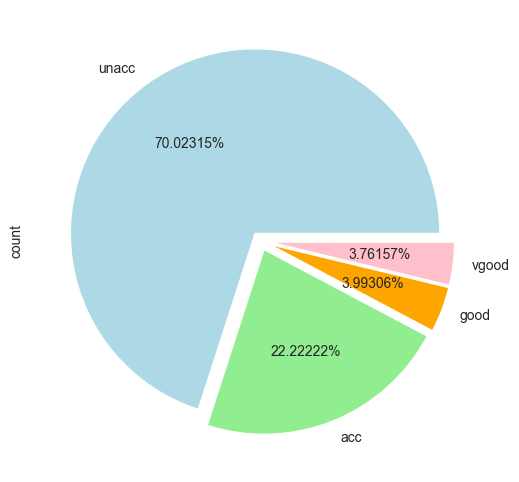

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style('darkgrid')

cols = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
cars = pd.read_csv('car_evaluation.csv', names=cols, header=None)

plot_size = plt.rcParams["figure.figsize"]
plot_size[0] = 8
plot_size[1] = 6
plt.rcParams["figure.figsize"] = plot_size

cars.output.value_counts().plot(kind='pie' , autopct='%0.05f%%', colors=['lightblue', 'lightgreen', 'orange', 'pink'], explode=[0.05]*4)

price = pd.get_dummies(cars.price, prefix='price')
maint = pd.get_dummies(cars.maint, prefix='maint')
doors = pd.get_dummies(cars.doors, prefix='doors')
persons = pd.get_dummies(cars.persons, prefix='persons')
lug_capacity = pd.get_dummies(cars.lug_capacity, prefix='lug_capacity')
safety = pd.get_dummies(cars.safety, prefix='safety')
labels = pd.get_dummies(cars.output, prefix='condition')

X = pd.concat([price, maint, doors, persons, lug_capacity, safety], axis=1)
y = labels.values

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from tensorflow.keras.layers import Dense, Input, Dropout, Activation
from tensorflow.keras.models import Model

input_layer = Input(shape=(X_train.shape[1],))
dense_layer_1 = Dense(15, activation='relu')(input_layer)

dense_layer_2 = Dense(10, 
activation='relu')(dense_layer_1)

output = Dense(y.shape[1], activation='softmax')(dense_layer_2)

model = Model(inputs=input_layer, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 534 (2.09 KB)

 Trainable params: 534 (2.09 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=8, verbose=1)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.2862 - loss: 1.4170 - val_acc: 0.6498 - val_loss: 1.0663
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7388 - loss: 0.8383 - val_acc: 0.6679 - val_loss: 0.7644
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7770 - loss: 0.5691 - val_acc: 0.7365 - val_loss: 0.5868
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8308 - loss: 0.4401 - val_acc: 0.7798 - val_loss: 0.4996
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8622 - loss: 0.3662 - val_acc: 0.8339 - val_loss: 0.4417
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8746 - loss: 0.3215 - val_acc: 0.8484 - val_loss: 0.4090
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8916 - loss: 0.2743 - val_acc: 0.8339 - val_loss: 0.3815
Epoch 8/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8762 - loss: 0.2924 - val_acc: 0.8159 - val_loss: 0.3655
Epoch 9/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac

In [6]:
scores = model.evaluate(X_test, y_test, verbose=1)
print("scores:", scores)
print("accuracy:", scores[1])

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9585 - loss: 0.0966 
scores: [0.08006134629249573, 0.9710982441902161]
accuracy: 0.9710982441902161
